# Build the Seven-County Study Area and EV Station Inventory

## Goal

Download the 2025 Census TIGER/Line county boundaries, select the seven Northeast Georgia study counties, spatially assign AFDC charging units to counties, and export spatial layers, a county inventory, and the first infrastructure map.

Official boundary source: https://www.census.gov/geographies/mapping-files/2025/geo/tiger-line-file.html

## Setup

The analysis uses a spatial join rather than city names or ZIP codes. This reliably assigns each charging location to its containing county. Georgia is identified by state FIPS code `13`.

In [1]:
from pathlib import Path
from urllib.request import Request, urlopen

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path(r"C:\Users\cason\GIS_Portfolio_3\Project 4 - EV Charging Suitability")
BOUNDARY_DIR = PROJECT_ROOT / "data" / "raw" / "boundaries"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
SPATIAL_DIR = PROJECT_ROOT / "outputs" / "spatial"
TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
MAP_DIR = PROJECT_ROOT / "maps"

for folder in [BOUNDARY_DIR, PROCESSED_DIR, SPATIAL_DIR, TABLE_DIR, MAP_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

STUDY_COUNTIES = ["Barrow", "Clarke", "Gwinnett", "Hall", "Jackson", "Oconee", "Walton"]
GEORGIA_FIPS = "13"
TIGER_URL = "https://www2.census.gov/geo/tiger/TIGER2025/COUNTY/tl_2025_us_county.zip"
county_zip = BOUNDARY_DIR / "tl_2025_us_county.zip"

station_candidates = sorted(
    (PROJECT_ROOT / "data" / "raw" / "charging_stations").glob("afdc_ev_charging_units_ga_*.csv"),
    key=lambda path: path.stat().st_mtime,
    reverse=True,
)
station_candidates = [path for path in station_candidates if not path.name.endswith("_metadata.csv")]
if not station_candidates:
    raise FileNotFoundError("Run notebook 02 first to download the AFDC Georgia charging-unit CSV.")
station_csv = station_candidates[0]

print("AFDC input:", station_csv.name)
print("Study counties:", ", ".join(STUDY_COUNTIES))

AFDC input: afdc_ev_charging_units_ga_2026-07-26.csv
Study counties: Barrow, Clarke, Gwinnett, Hall, Jackson, Oconee, Walton


## Steps

### 1. Download and select the Census county boundaries

In [2]:
if not county_zip.exists():
    request = Request(TIGER_URL, headers={"User-Agent": "GIS-Portfolio-EV-Suitability/1.0"})
    with urlopen(request, timeout=120) as response:
        county_zip.write_bytes(response.read())

us_counties = gpd.read_file(f"zip://{county_zip}")
georgia_counties = us_counties.loc[us_counties["STATEFP"] == GEORGIA_FIPS].copy()
study_counties = georgia_counties.loc[georgia_counties["NAME"].isin(STUDY_COUNTIES)].copy()
study_counties = study_counties.sort_values("NAME").reset_index(drop=True)

missing_counties = sorted(set(STUDY_COUNTIES) - set(study_counties["NAME"]))
assert len(study_counties) == 7, f"Expected 7 counties; missing: {missing_counties}"

study_counties.to_file(SPATIAL_DIR / "study_area_counties.gpkg", layer="study_counties", driver="GPKG")
display(study_counties[["NAME", "GEOID", "ALAND", "AWATER"]])

,NAME,GEOID,ALAND,AWATER
0,Barrow,13013,417261505,4725595
1,Clarke,13059,308985554,4776726
2,Gwinnett,13135,1116635239,15672305
3,Hall,13139,1016590900,93546822
4,Jackson,13157,879817681,8785542
5,Oconee,13219,477493473,5214512
6,Walton,13297,846461070,8234175


### 2. Create station points and spatially assign counties

In [3]:
stations = pd.read_csv(station_csv, low_memory=False)
stations = stations.dropna(subset=["Longitude", "Latitude"]).copy()
stations_gdf = gpd.GeoDataFrame(
    stations,
    geometry=gpd.points_from_xy(stations["Longitude"], stations["Latitude"]),
    crs="EPSG:4326",
)

study_counties = study_counties.to_crs(stations_gdf.crs)
study_units = gpd.sjoin(
    stations_gdf,
    study_counties[["NAME", "GEOID", "geometry"]],
    how="inner",
    predicate="within",
).rename(columns={"NAME": "County", "GEOID": "County GEOID"})
study_units = study_units.drop(columns=["index_right"])

assert set(study_units["County"]).issubset(STUDY_COUNTIES)
assert not study_units.empty, "No AFDC charging units intersected the study area."

study_units.to_file(SPATIAL_DIR / "existing_ev_charging_units.gpkg", layer="charging_units", driver="GPKG")
print(f"Charging-unit rows in study area: {len(study_units):,}")
print(f"Unique station IDs: {study_units['ID'].nunique():,}")

Charging-unit rows in study area: 862
Unique station IDs: 272


### 3. Build a county-level station and port inventory

In [4]:
port_fields = ["EV Level1 EVSE Num", "EV Level2 EVSE Num", "EV DC Fast Count"]
for field in port_fields:
    study_units[field] = pd.to_numeric(study_units.get(field, 0), errors="coerce").fillna(0)

# Station-level fields repeat across charging-unit rows, so deduplicate before summing station totals.
station_level = study_units.sort_values("ID").drop_duplicates(subset="ID")
county_inventory = (
    station_level.groupby("County", as_index=False)
    .agg(
        stations=("ID", "nunique"),
        level_1_ports=("EV Level1 EVSE Num", "sum"),
        level_2_ports=("EV Level2 EVSE Num", "sum"),
        dc_fast_ports=("EV DC Fast Count", "sum"),
    )
)
county_inventory["total_ports"] = county_inventory[["level_1_ports", "level_2_ports", "dc_fast_ports"]].sum(axis=1)
county_inventory = county_inventory.sort_values("total_ports", ascending=False)
county_inventory.to_csv(TABLE_DIR / "existing_charging_inventory_by_county.csv", index=False)
display(county_inventory)

,County,stations,level_1_ports,level_2_ports,dc_fast_ports,total_ports
2,Gwinnett,175,0.0,385.0,174.0,559.0
3,Hall,30,0.0,65.0,46.0,111.0
1,Clarke,36,0.0,69.0,32.0,101.0
0,Barrow,13,0.0,29.0,9.0,38.0
5,Oconee,8,0.0,16.0,10.0,26.0
6,Walton,5,0.0,8.0,6.0,14.0
4,Jackson,5,0.0,8.0,5.0,13.0


### 4. Create the existing-infrastructure map

Blue circles represent Level 2-only stations. Orange diamonds identify stations with at least one DC fast port, using both color and shape so the distinction does not rely on color alone.

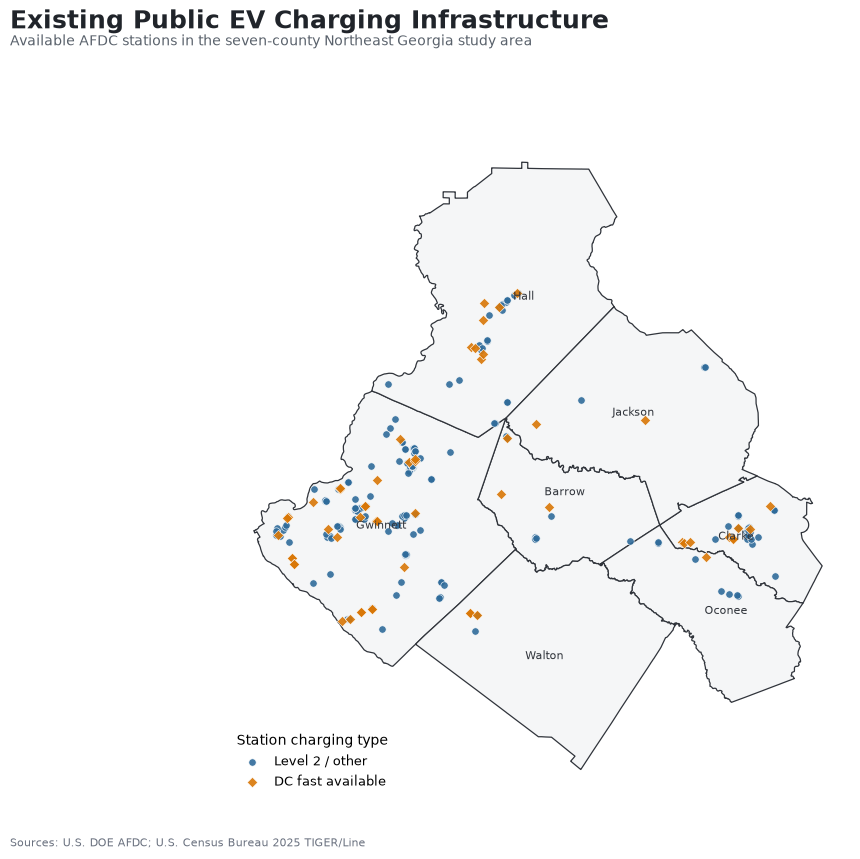

Saved: C:\Users\cason\GIS_Portfolio_3\Project 4 - EV Charging Suitability\maps\existing_ev_charging_infrastructure.png


In [5]:
station_points = station_level.copy()
station_points["Charging Type"] = station_points["EV DC Fast Count"].gt(0).map({True: "DC fast available", False: "Level 2 / other"})

fig, ax = plt.subplots(figsize=(12, 9), facecolor="white")
study_counties.plot(ax=ax, color="#F5F6F7", edgecolor="#30343B", linewidth=0.9)

styles = {
    "Level 2 / other": {"color": "#2F6B9A", "marker": "o", "label": "Level 2 / other"},
    "DC fast available": {"color": "#D97706", "marker": "D", "label": "DC fast available"},
}
for charging_type, style in styles.items():
    subset = station_points.loc[station_points["Charging Type"] == charging_type]
    subset.plot(
        ax=ax, color=style["color"], marker=style["marker"], markersize=28,
        edgecolor="white", linewidth=0.45, alpha=0.9, label=style["label"],
    )

for _, county in study_counties.iterrows():
    label_point = county.geometry.representative_point()
    ax.annotate(county["NAME"], (label_point.x, label_point.y), ha="center", fontsize=8, color="#30343B")

fig.suptitle("Existing Public EV Charging Infrastructure", x=0.07, y=0.965, ha="left", fontsize=18, weight="bold", color="#20242A")
fig.text(0.07, 0.925, "Available AFDC stations in the seven-county Northeast Georgia study area", fontsize=10, color="#59616B")
ax.legend(title="Station charging type", frameon=False, loc="lower left", fontsize=9, title_fontsize=10)
ax.set_axis_off()
fig.text(0.07, 0.035, "Sources: U.S. DOE AFDC; U.S. Census Bureau 2025 TIGER/Line", fontsize=8, color="#6B7280")
plt.tight_layout(rect=[0.04, 0.07, 0.98, 0.89])

map_path = MAP_DIR / "existing_ev_charging_infrastructure.png"
fig.savefig(map_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved:", map_path)

## Checks

The seven county names must all be present, station IDs must be unique in the inventory layer, all station coordinates must fall inside the study area, and all required outputs must exist.

In [6]:
expected_outputs = [
    SPATIAL_DIR / "study_area_counties.gpkg",
    SPATIAL_DIR / "existing_ev_charging_units.gpkg",
    TABLE_DIR / "existing_charging_inventory_by_county.csv",
    MAP_DIR / "existing_ev_charging_infrastructure.png",
]

assert set(study_counties["NAME"]) == set(STUDY_COUNTIES)
assert station_level["ID"].is_unique
assert study_units.geometry.notna().all()
assert all(path.exists() for path in expected_outputs)

print("All study-area and output checks passed.")
for path in expected_outputs:
    print("Exists: True |", path)

All study-area and output checks passed.
Exists: True | C:\Users\cason\GIS_Portfolio_3\Project 4 - EV Charging Suitability\outputs\spatial\study_area_counties.gpkg
Exists: True | C:\Users\cason\GIS_Portfolio_3\Project 4 - EV Charging Suitability\outputs\spatial\existing_ev_charging_units.gpkg
Exists: True | C:\Users\cason\GIS_Portfolio_3\Project 4 - EV Charging Suitability\outputs\tables\existing_charging_inventory_by_county.csv
Exists: True | C:\Users\cason\GIS_Portfolio_3\Project 4 - EV Charging Suitability\maps\existing_ev_charging_infrastructure.png


## Next Steps

Download ACS 2020–2024 block-group variables for population, households, income, renters, multifamily housing, and vehicle availability. Those variables will support the charging-demand and equity models.